MATERIAL                           | eps_rf (xx, yy)   
----------------------------------------------------------------------------------------
LiNbO3 slab + ribs                 | (28.0, 44.0)      
SiO2 box + caps                    | (3.9, 3.9)        
Silicon substrate                  | (11.7, 11.7)      
Air / vacuum                       | (1.0, 1.0)        
Gold electrodes (PEC + IBC, Rs = 72.07 mOhm/sq) | (1.0, 1.0)        
f0 = 60.0 GHz   lambda0 = 4.997 mm   gold skin depth = 304.2 nm   Rs = 72.07 mOhm/sq
cross-section  W_S = 60.952  GAP = 4.448  MTX = 13.336  W_G = 70.0 um
tee            W1 = 38.109  W2 = 25.994  L1 = 51.387  L2 = 173.248 um   pitch 200.0 um
               slot reaches 64.10 um into the 70.0 um ground, leaving a 5.90 um rim
unetched mesh  44644 triangles, built in 3.9 s
----------------------------------------------------------------------------------------
one period contains these cross-sections:
   stem + cap open    51.39 um (25.7 % of the period)   gr

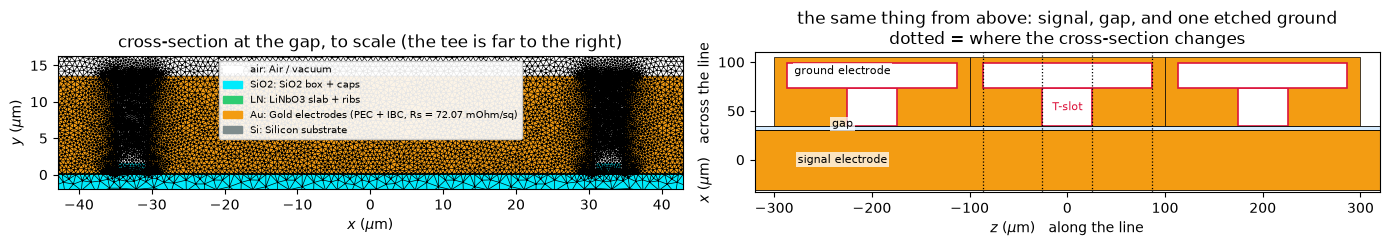

In [1]:
# %% [0] Geometry, Mesh & Material Configuration  --  the tee-etched unit cell
#
# Same cross-section as RF_interface_optimized.ipynb, with a T-shaped slot cut
# through the ground electrodes every PITCH micrometres.
#
# The slot is two rectangles, both cut through the full electrode thickness:
#     stem   W1 wide (across the line), L1 long (along the line), touching
#            the ground's inner edge
#     cap    W2 wide, L2 long, immediately outside the stem
#
# Because L1 and L2 differ, the cross-section is not the same everywhere along
# one period -- it takes a small number of distinct forms, listed at the bottom
# of this cell.  Cell [2] solves each one and averages them by length; that
# average IS the etched line, because the pitch is 13x shorter than the guided
# wavelength.  Cell [1] first solves the unetched cross-section on its own, so
# the baseline can be checked against RF_interface_optimized.ipynb before any
# perturbation is trusted.
import logging
import time
import warnings
from collections import OrderedDict

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
from shapely.affinity import scale as _scale
from shapely.geometry import MultiPolygon, Polygon, box
from shapely.ops import unary_union
from skfem import (Basis, BilinearForm, ElementTriP0, ElementTriP1, Functional,
                   InteriorFacetBasis, LinearForm, MeshTri, asm, condense, solve)
from skfem.helpers import dot, grad
from femwell.mesh import mesh_from_OrderedDict

warnings.filterwarnings("ignore")
logging.getLogger("skfem").setLevel(logging.ERROR)

# ============================================================
# 1. PARAMETER BLOCK   (cross-section names follow the COMSOL .mph list)
# ============================================================
f0        = 60.0e9      # Hz    extraction frequency

auc_w     = 60.952      # um    W_S       central signal electrode width
gap       = 4.448       # um    GAP       signal-to-ground gap
au_h      = 13.336      # um    MTX       electrode thickness
aul_w     = 70.0        # um    W_G       ground electrode width
cap_w     = 3.340       # um    cap_w     SiO2 cap width
cap_h     = 1.40        # um    SiO2 cap height

tfln      = 0.460       # um    thin-film LN thickness
wg_h      = 0.267       # um    ETCH_DEPTH rib height
slab_h    = tfln - wg_h # um    un-etched slab under the rib
wg_top    = 0.80        # um    rib top base
theta     = 60.0        # deg   rib sidewall angle

box_h     = 4.7         # um    buried SiO2
si_h      = 550.0       # um    silicon substrate
air_h     = 550.0       # um    air cap
lat_pad   = 200.0       # um    lateral padding per side

# ---- THE TEE -----------------------------------------------------------
PITCH     = 200.0       # um    slot pitch along the line
W1        = 38.109      # um    stem width, measured out from the ground inner edge
L1        = 51.387      # um    stem length along the line
W2        = 25.994      # um    cap width, immediately outside the stem
L2        = 173.248     # um    cap length along the line
# ------------------------------------------------------------------------

basetta   = wg_h / np.tan(np.deg2rad(theta))
wg_bottom = wg_top + 2.0 * basetta
x_sig  = auc_w / 2.0            # signal spans [-x_sig, +x_sig]
x_gi   = x_sig + gap            # ground inner edge
x_go   = x_gi + aul_w           # ground outer edge
x_dom  = x_go + lat_pad         # domain half width
x_wg   = x_sig + gap / 2.0      # rib centre
y_el   = slab_h + au_h          # electrode top
y_rib  = slab_h + wg_h          # rib top

# ============================================================
# 2. MATERIALS   (60 GHz)
# ============================================================
C0   = 299792458.0
EPS0 = 8.8541878128e-12
MU0  = 4.0e-7 * np.pi
DB_PER_NEPER = 20.0 * np.log10(np.e)

SIGMA_AU = 4.561e7                                   # S/m
skin_au  = np.sqrt(2.0 / (2 * np.pi * f0 * MU0 * SIGMA_AU))
Rs_au    = 1.0 / (SIGMA_AU * skin_au)                # ohm/square

MATERIALS = {
    "LN":   {"color": "#2ecc71", "eps_rf": (28.0, 44.0), "desc": "LiNbO3 slab + ribs"},
    "SiO2": {"color": "#00ebfc", "eps_rf": (3.9, 3.9),   "desc": "SiO2 box + caps"},
    "Si":   {"color": "#7f8c8d", "eps_rf": (11.7, 11.7), "desc": "Silicon substrate"},
    "air":  {"color": "#ffffff", "eps_rf": (1.0, 1.0),   "desc": "Air / vacuum"},
    "Au":   {"color": "#f39c12", "eps_rf": (1.0, 1.0),
             "desc": f"Gold electrodes (PEC + IBC, Rs = {Rs_au*1e3:.2f} mOhm/sq)"},
}
EPS = {k: v["eps_rf"] for k, v in MATERIALS.items()}

# ============================================================
# 3. THE z-SECTIONS ONE PERIOD SPLITS INTO
# ============================================================
def tee_sections(w1=None, w2=None, l1=None, l2=None, p=None):
    """(length, ground metal strips, label) for each distinct cross-section."""
    w1 = W1 if w1 is None else w1; w2 = W2 if w2 is None else w2
    l1 = L1 if l1 is None else l1; l2 = L2 if l2 is None else l2
    p = PITCH if p is None else p
    a, b, c = x_gi, min(x_gi + w1, x_go), min(x_gi + w1 + w2, x_go)
    lo, hi = min(l1, l2), max(l1, l2)
    out = [(lo,      [(c, x_go)],             "stem + cap open"),
           (hi - lo, [(a, b), (c, x_go)] if l2 >= l1 else [(b, x_go)],
                     "cap open" if l2 >= l1 else "stem open"),
           (p - hi,  [(x_gi, x_go)],          "no slot")]
    return [(ln, sp, nm) for ln, sp, nm in out if ln > 1e-9]


SECTIONS = tee_sections()

# ============================================================
# 4. MESH
# ============================================================
MESH_FACTOR = 2.5      # 1.0 = the RF_interface_optimized setting; 2.5 is ~5x faster
CORNER_BOX  = 0.25     # um, half-size of the refinement box on each metal corner
CORNER_RES  = 0.12     # um, mesh size inside those boxes (drives the loss integral)
SKIN_T      = 0.10     # um, thickness of the conductor-surface collar
SKIN_REACH  = 5.0      # um, how far that collar runs along the top / bottom faces
SKIN_RES    = 0.25     # um, mesh size inside the collar


def _mirror(p):
    return _scale(p, xfact=-1.0, yfact=1.0, origin=(0, 0))


def _clean(g):
    if g.is_empty or g.area < 2.0e-4:
        return None
    if not g.interiors and g.length > 0 and 4.0 * g.area / g.length < 8.0e-3:
        return None
    return g


def _geomify(g):
    """Sanitised Polygon / MultiPolygon.  Slivers are dropped: gmsh snaps their
    vertices together and then cannot close the curve loop."""
    if g.is_empty:
        return None
    try:
        g = g.buffer(0)
    except Exception:
        pass
    parts = list(g.geoms) if hasattr(g, "geoms") else [g]
    keep = [c for c in (_clean(x) for x in parts
                        if getattr(x, "geom_type", "") == "Polygon") if c is not None]
    if not keep:
        return None
    return keep[0] if len(keep) == 1 else MultiPolygon(keep)


def wall_pitch(xs):
    s = np.sort(np.unique(np.round(np.asarray(xs, float), 9)))
    return float(np.min(np.diff(s))) if s.size > 1 else 2 * SKIN_REACH


# one clamp shared by every mesh in the notebook, so the refinement is identical
# on both sides of the etched - unetched subtraction and its bias cancels
_walls = [-x_sig, x_sig]
for _, _sp, _ in SECTIONS:
    for _a, _b in _sp:
        _walls += [_a, _b, -_a, -_b]
MIN_PITCH = wall_pitch(_walls)


def build(ground_spans=None):
    """2D cross-section.  `ground_spans` lists the surviving ground metal
    strips; None is the solid unetched ground."""
    spans = [(a, b) for a, b in (ground_spans or [(x_gi, x_go)]) if b - a > 1e-9]
    corner_box = min(CORNER_BOX, 0.30 * MIN_PITCH)
    skin_t = min(SKIN_T, 0.30 * MIN_PITCH)
    skin_reach = min(SKIN_REACH, 0.40 * MIN_PITCH)

    def rib(xc):
        return Polygon([(xc - wg_bottom / 2, slab_h), (xc - wg_top / 2, y_rib),
                        (xc + wg_top / 2, y_rib), (xc + wg_bottom / 2, slab_h)])

    rib_r = rib(x_wg); rib_l = _mirror(rib_r)
    cap_r = box(x_wg - cap_w / 2, slab_h, x_wg + cap_w / 2,
                slab_h + cap_h).difference(rib_r)
    cap_l = _mirror(cap_r)
    el_sig = box(-x_sig, slab_h, x_sig, y_el)
    gnd_r = [box(a, slab_h, b, y_el) for a, b in spans]
    gnd_l = [_mirror(g) for g in gnd_r]
    solids = unary_union([el_sig] + gnd_r + gnd_l + [cap_r, cap_l, rib_r, rib_l])

    wall_x = [-x_sig, x_sig]
    for a, b in spans:
        wall_x += [a, b, -a, -b]
    corner_ring = unary_union(
        [box(xc - corner_box, yc - corner_box, xc + corner_box, yc + corner_box)
         for xc in wall_x for yc in (slab_h, y_el)]).difference(solids)
    walls = []
    for xc in wall_x:
        walls.append(box(xc - skin_t, slab_h, xc + skin_t, y_el))
        walls.append(box(xc - skin_reach, y_el, xc + skin_reach, y_el + skin_t))
        walls.append(box(xc - skin_reach, slab_h - skin_t, xc + skin_reach, slab_h))
    skin_ring = unary_union(walls).difference(unary_union([solids, corner_ring]))

    cut = unary_union([solids, corner_ring, skin_ring])
    air_gap = box(-x_go - 2.0, slab_h, x_go + 2.0, slab_h + au_h + 4.0).difference(cut)
    air_near = box(-x_go - 15.0, slab_h, x_go + 15.0,
                   slab_h + au_h + 15.0).difference(unary_union([cut, air_gap]))
    air_far = box(-x_dom, slab_h, x_dom, slab_h + air_h).difference(
        unary_union([cut, air_gap, air_near]))
    slab_near = box(-x_go - 15.0, 0.0, x_go + 15.0, slab_h).difference(
        unary_union([corner_ring, skin_ring]))
    slab_far = box(-x_dom, 0.0, x_dom, slab_h).difference(slab_near)
    box_near = box(-x_go - 15.0, -box_h, x_go + 15.0, 0.0)
    box_far = box(-x_dom, -box_h, x_dom, 0.0).difference(box_near)
    si = box(-x_dom, -box_h - si_h, x_dom, -box_h)

    polys, r2m, res, dist = OrderedDict(), {}, {}, {}

    def put(name, g, material, resolution, distance):
        g = _geomify(g)
        if g is not None:
            polys[name] = g; r2m[name] = material
            res[name] = resolution; dist[name] = distance

    put("corner_ring", corner_ring, "air", CORNER_RES, 0.6)
    put("skin_ring", skin_ring, "air", SKIN_RES, 1.0)
    put("cap_r", cap_r, "SiO2", 0.20, 1.0); put("cap_l", cap_l, "SiO2", 0.20, 1.0)
    put("rib_r", rib_r, "LN", 0.12, 1.0); put("rib_l", rib_l, "LN", 0.12, 1.0)
    put("el_sig", el_sig, "Au", 0.80, 3.0)
    put("el_gr", unary_union(gnd_r), "Au", 0.80, 3.0)
    put("el_gl", unary_union(gnd_l), "Au", 0.80, 3.0)
    put("air_gap", air_gap, "air", 0.30, 3.0)
    put("slab_near", slab_near, "LN", 0.25, 3.0)
    put("air_near", air_near, "air", 2.0, 10.0)
    put("box_near", box_near, "SiO2", 2.0, 5.0)
    put("slab_far", slab_far, "LN", 6.0, 10.0)
    put("box_far", box_far, "SiO2", 6.0, 10.0)
    put("si", si, "Si", 30.0, 30.0)
    put("air_far", air_far, "air", 30.0, 30.0)

    resolutions = {k: {"resolution": res[k] * (1.0 if k.endswith("_ring")
                                               else MESH_FACTOR),
                       "distance": dist[k]} for k in polys}
    raw = mesh_from_OrderedDict(polys, resolutions=resolutions,
                                default_resolution_min=0.4 * min(CORNER_RES, SKIN_RES),
                                default_resolution_max=35.0)
    mesh = MeshTri(raw.points[:, :2].T, raw.cells_dict["triangle"].T)
    sub = raw.cell_data_dict["gmsh:physical"]["triangle"]
    n2i = {n: (d[0] if hasattr(d, "__getitem__") else d)
           for n, d in raw.field_data.items()}
    region = np.empty(mesh.nelements, dtype=object)
    for rn, sid in n2i.items():
        bn = rn.split("___")[0]
        if bn in polys:
            region[sub == sid] = bn
    region = region.astype(str)
    mat = np.array([r2m[r] for r in region], dtype=object)
    coll = np.isin(region, ("corner_ring", "skin_ring"))
    if coll.any():
        yc = mesh.p[1, mesh.t].mean(axis=0)
        mat[coll] = np.where(yc < 0.0, "SiO2", np.where(yc < slab_h, "LN", "air"))[coll]
    return dict(mesh=mesh, region=region, mat=mat, spans=spans,
                is_metal=np.isin(region, ("el_sig", "el_gr", "el_gl")),
                is_sig=region == "el_sig")


t_mesh = time.time()
G_UNETCHED = build(None)
t_mesh = time.time() - t_mesh

print("=" * 88)
print(f"{'MATERIAL':<34} | {'eps_rf (xx, yy)':<18}")
print("-" * 88)
for key, d in MATERIALS.items():
    e = d["eps_rf"]
    print(f"{d['desc']:<34} | {f'({e[0]:.1f}, {e[1]:.1f})':<18}")
print("=" * 88)
print(f"f0 = {f0/1e9:.1f} GHz   lambda0 = {C0/f0*1e3:.3f} mm   "
      f"gold skin depth = {skin_au*1e9:.1f} nm   Rs = {Rs_au*1e3:.2f} mOhm/sq")
print(f"cross-section  W_S = {auc_w:.3f}  GAP = {gap:.3f}  MTX = {au_h:.3f}  "
      f"W_G = {aul_w:.1f} um")
print(f"tee            W1 = {W1:.3f}  W2 = {W2:.3f}  L1 = {L1:.3f}  L2 = {L2:.3f} um"
      f"   pitch {PITCH:.1f} um")
print(f"               slot reaches {W1+W2:.2f} um into the {aul_w:.1f} um ground, "
      f"leaving a {aul_w-W1-W2:.2f} um rim")
print(f"unetched mesh  {G_UNETCHED['mesh'].nelements} triangles, built in {t_mesh:.1f} s")
print("-" * 88)
print("one period contains these cross-sections:")
for ln, sp, nm in SECTIONS:
    print(f"   {nm:<16} {ln:7.2f} um ({100*ln/PITCH:4.1f} % of the period)   "
          f"ground metal at " + ", ".join(f"[{a:.2f}, {b:.2f}]" for a, b in sp))
print("=" * 88)

# ---- preview ---------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14.0, 4.6))

ax = axes[0]
seen, patches = set(), []
for region in np.unique(G_UNETCHED["region"]):
    idx = np.where(G_UNETCHED["region"] == region)[0]
    key = G_UNETCHED["mat"][idx[0]] if region.endswith("_ring") else None
    key = key or {"el_sig": "Au", "el_gr": "Au", "el_gl": "Au"}.get(
        region, G_UNETCHED["mat"][idx[0]])
    sub = MeshTri(G_UNETCHED["mesh"].p, G_UNETCHED["mesh"].t[:, idx])
    sub.plot(np.zeros(sub.nelements), ax=ax, shading="flat",
             cmap=plt.matplotlib.colors.ListedColormap([MATERIALS[key]["color"]]))
    if key not in seen:
        patches.append(mpatches.Patch(color=MATERIALS[key]["color"],
                                      label=f"{key}: {MATERIALS[key]['desc']}"))
        seen.add(key)
G_UNETCHED["mesh"].draw(ax=ax, color="black", lw=0.12)
ax.set_xlim(-x_gi - 8, x_gi + 8); ax.set_ylim(-2.0, au_h + 3.0)
ax.set_aspect("equal")
ax.set_xlabel(r"$x$ ($\mu$m)"); ax.set_ylabel(r"$y$ ($\mu$m)")
ax.set_title("cross-section at the gap, to scale (the tee is far to the right)")
ax.legend(handles=patches, loc="upper center", fontsize=7, framealpha=0.9)

ax = axes[1]
for k in (-1, 0, 1):
    z0 = k * PITCH
    ax.add_patch(Rectangle((z0 - PITCH / 2, x_gi), PITCH, aul_w,
                           fc=MATERIALS["Au"]["color"], ec="k", lw=0.5))
    ax.add_patch(Rectangle((z0 - L1 / 2, x_gi), L1, W1, fc="w", ec="crimson", lw=1.2))
    ax.add_patch(Rectangle((z0 - L2 / 2, x_gi + W1), L2, W2, fc="w",
                           ec="crimson", lw=1.2))
ax.add_patch(Rectangle((-1.6 * PITCH, x_sig), 3.2 * PITCH, gap,
                       fc="#d6ecff", ec="k", lw=0.6))
ax.add_patch(Rectangle((-1.6 * PITCH, -x_sig), 3.2 * PITCH, 2 * x_sig,
                       fc=MATERIALS["Au"]["color"], ec="k", lw=0.6))
_ann = dict(ha="center", va="center", fontsize=8,
            bbox=dict(fc="w", ec="none", alpha=0.75, pad=1.2))
ax.annotate("signal electrode", (-1.15 * PITCH, 0.0), **_ann)
ax.annotate("gap", (-1.15 * PITCH, x_sig + gap / 2 + 4), **_ann)
ax.annotate("ground electrode", (-1.15 * PITCH, x_gi + 0.80 * aul_w), **_ann)
ax.annotate("T-slot", (0.0, x_gi + W1 / 2), color="crimson", **_ann)
for zb in (L1 / 2, L2 / 2):
    for s in (-1, 1):
        ax.axvline(s * zb, color="k", ls=":", lw=0.9)
ax.set_xlim(-1.6 * PITCH, 1.6 * PITCH); ax.set_ylim(-x_sig - 3, x_go + 5)
ax.set_aspect("equal")
ax.set_xlabel(r"$z$ ($\mu$m)   along the line")
ax.set_ylabel(r"$x$ ($\mu$m)   across the line")
ax.set_title("the same thing from above: signal, gap, and one etched ground\n"
             "dotted = where the cross-section changes")
plt.tight_layout(); plt.show()


In [2]:
# %% [1] Quasi-static extraction, and the unetched baseline
#
# Exactly the extraction of RF_interface_optimized.ipynb cell [1]:
#     C      anisotropic Laplace, V = 1 on the signal, 0 on the grounds
#     C_air  the same with every eps set to 1;   L = 1/(c^2 C_air)
#     n_m    c sqrt(L C),      Z0 = sqrt(L/C)
#     R'     Rs * contour integral of |E_air . n|^2 / (C_air/eps0)^2
#            -- Wheeler's incremental-inductance rule as a contour integral
#     alpha  R'/(2 Z0), in dB/cm
#
# Run it on the unetched cross-section first.  These numbers must match the
# baseline notebook before anything below is worth reading.
@BilinearForm
def _laplace(u, v, w):
    return w.ex * grad(u)[0] * grad(v)[0] + w.ey * grad(u)[1] * grad(v)[1]


@Functional
def _dvdn2(w):
    return (w.gu.grad[0] * w.nx + w.gu.grad[1] * w.ny) ** 2


def extract(g):
    """C, C_air, L, R', n_m, Z0, alpha for one cross-section."""
    mesh, mat = g["mesh"], g["mat"]
    is_metal, is_sig = g["is_metal"], g["is_sig"]
    basis = Basis(mesh, ElementTriP1())
    bp0 = basis.with_element(ElementTriP0())
    ex = np.array([EPS[m][0] for m in mat])
    ey = np.array([EPS[m][1] for m in mat])
    one = np.ones(mesh.nelements)
    dofs_sig = np.unique(basis.element_dofs[:, np.where(is_sig)[0]])
    dofs_D = np.unique(basis.element_dofs[:, np.where(is_metal)[0]])

    def solve_potential(a, b):
        K = asm(_laplace, basis, ex=bp0.interpolate(a), ey=bp0.interpolate(b))
        uD = np.zeros(basis.N); uD[dofs_sig] = 1.0
        Kc, fc, uc, I = condense(K, np.zeros(basis.N), x=uD, D=dofs_D)
        u = uc.copy(); u[I] = solve(Kc, fc)
        return u, EPS0 * float((K @ u)[dofs_sig].sum())

    _, C = solve_potential(ex, ey)
    V_air, C_air = solve_potential(one, one)

    f2t = mesh.f2t
    on = (f2t[1] >= 0) & (is_metal[f2t[0]] ^ is_metal[f2t[1]])
    integral = 0.0
    for side in (0, 1):
        other = 1 - side
        fac = np.where(on & is_metal[f2t[other]] & ~is_metal[f2t[side]])[0]
        if fac.size == 0:
            continue
        p = mesh.p[:, mesh.facets[:, fac]]
        tan = p[:, 1, :] - p[:, 0, :]
        nrm = np.vstack([tan[1], -tan[0]]); nrm /= np.linalg.norm(nrm, axis=0)
        mid = p.mean(axis=1)
        cen = mesh.p[:, mesh.t[:, f2t[other][fac]]].mean(axis=1)
        nrm *= np.sign(((mid - cen) * nrm).sum(axis=0))
        fb = InteriorFacetBasis(mesh, ElementTriP1(), facets=fac, side=side)
        integral += _dvdn2.assemble(fb, gu=fb.interpolate(V_air),
                                    nx=nrm[0][:, None], ny=nrm[1][:, None])
    Rp = Rs_au * 1e6 * integral / (C_air / EPS0) ** 2       # ohm/m
    return line_params(C, 1.0 / (C0 ** 2 * C_air), Rp, C_air=C_air,
                       ntri=mesh.nelements)


def line_params(C, L, Rp, **extra):
    Z0 = np.sqrt(L / C)
    return dict(C=C, L=L, Rp=Rp, Z0=Z0, n_m=C0 * np.sqrt(L * C),
                alpha=DB_PER_NEPER * (Rp / (2.0 * Z0)) / 100.0, **extra)


def show(label, r):
    print(f"  {label:<22} C = {r['C']*1e12:8.3f} pF/m   L = {r['L']*1e9:8.3f} nH/m   "
          f"R' = {r['Rp']/1e3:7.3f} kOhm/m")
    print(f"  {'':<22} n_m = {r['n_m']:.4f}      Z0 = {r['Z0']:7.3f} ohm      "
          f"alpha = {r['alpha']:.4f} dB/cm")


t0 = time.time()
UNETCHED = extract(G_UNETCHED)
print("=" * 88)
print("UNETCHED BASELINE  (no tee)  --  compare this against "
      "RF_interface_optimized.ipynb")
print("-" * 88)
show("unetched line", UNETCHED)
print(f"  {'':<22} {UNETCHED['ntri']} triangles, {time.time()-t0:.1f} s   "
      f"(MESH_FACTOR = {MESH_FACTOR})")
print("-" * 88)
print("  This notebook runs a coarser mesh than the baseline notebook, so its")
print("  alpha sits a couple of percent low.  That bias is identical in the")
print("  etched and unetched runs and cancels exactly in every delta below.")
print("=" * 88)


UNETCHED BASELINE  (no tee)  --  compare this against RF_interface_optimized.ipynb
----------------------------------------------------------------------------------------
  unetched line          C =  258.336 pF/m   L =  111.778 nH/m   R' =   2.140 kOhm/m
                         n_m = 1.6110      Z0 =  20.801 ohm      alpha = 4.4672 dB/cm
                         44644 triangles, 0.7 s   (MESH_FACTOR = 2.5)
----------------------------------------------------------------------------------------
  This notebook runs a coarser mesh than the baseline notebook, so its
  alpha sits a couple of percent low.  That bias is identical in the
  etched and unetched runs and cancels exactly in every delta below.


In [3]:
# %% [2] The etched line
#
# Two contributions, both ohmic and reactive:
#
#   (a) the cross-section changes.  Solve each section of cell [0] and average
#       by length: charge adds in parallel along z, flux and dissipation add in
#       series.  Valid because the pitch is 13x shorter than the guided
#       wavelength, so the period homogenises.
#
#   (b) the current detours.  (a) leaves each section's current in its own 2D
#       pattern, but the slot interrupts the inner ground, so once per period
#       the return current must actually travel out to the surviving rim and
#       back.  That path is extra resistance.  Solve it as sheet conduction on
#       the ground seen from above: phi = -E0 z + psi with J = (1/Rs)(E0 zhat
#       - grad psi) and div J = 0; the slot rim and the ground edges carry no
#       current through them, and psi = 0 at the slot centre and midway between
#       slots, which builds the periodicity in without meshing many periods.
#       It is charged at the full Rs on one face and at the unetched Z0, both
#       of which OVERSTATE it, so this term is an upper bound.
@BilinearForm
def _sheet(u, v, w):
    return dot(grad(u), grad(v))


@LinearForm
def _drive(v, w):
    return grad(v)[1]


@Functional
def _dissipation(w):
    return w.gp.grad[0] ** 2 + (1.0 - w.gp.grad[1]) ** 2


def _grid(xs, zs):
    X, Z = np.meshgrid(xs, zs, indexing="ij")
    nz = len(zs)
    tri = [[i * nz + j, (i + 1) * nz + j, (i + 1) * nz + j + 1]
           for i in range(len(xs) - 1) for j in range(nz - 1)] + \
          [[i * nz + j, (i + 1) * nz + j + 1, i * nz + j + 1]
           for i in range(len(xs) - 1) for j in range(nz - 1)]
    return np.vstack([X.ravel(), Z.ravel()]), np.array(tri).T


def _axis(lo, hi, breaks, h):
    b = np.unique(np.clip(np.r_[lo, breaks, hi], lo, hi))
    return np.unique(np.concatenate(
        [np.linspace(b[k], b[k + 1], max(2, int(np.ceil((b[k + 1] - b[k]) / h)) + 1))
         for k in range(len(b) - 1)]))


def detour_squares(w1=W1, w2=W2, l1=L1, l2=L2, p=PITCH, h=0.5):
    """Squares of gold the return current crosses per half period, one ground."""
    a, b = x_gi, min(x_gi + w1, x_go)
    c = min(x_gi + w1 + w2, x_go)
    xs = _axis(x_gi, x_go, [b, c], h)
    zs = _axis(0.0, p / 2, [min(l1, p) / 2, min(l2, p) / 2], h)
    pts, t = _grid(xs, zs)
    xc, zc = pts[0, t].mean(axis=0), pts[1, t].mean(axis=0)
    keep = ~(((xc > a) & (xc < b) & (zc < l1 / 2)) |
             ((xc > b) & (xc < c) & (zc < l2 / 2)))
    t = t[:, keep]
    used = np.unique(t)                       # drop nodes stranded in the slot
    remap = np.full(pts.shape[1], -1, dtype=int); remap[used] = np.arange(used.size)
    m = MeshTri(pts[:, used], remap[t])
    basis = Basis(m, ElementTriP1())
    D = basis.get_dofs(lambda q: (np.abs(q[1]) < 1e-9) | (np.abs(q[1] - p / 2) < 1e-9))
    psi = solve(*condense(asm(_sheet, basis), asm(_drive, basis), D=D))
    Pd = _dissipation.assemble(basis, gp=basis.interpolate(psi))
    return float((p / 2.0) ** 2 / Pd) if Pd > 0 else np.nan


t0 = time.time()
PER_SECTION, acc = [], dict(C=0.0, L=0.0, Rp=0.0)
for ln, spans, name in SECTIONS:
    r = extract(build(spans))
    PER_SECTION.append((ln, name, r))
    for k in acc:
        acc[k] += ln * r[k]

N_SLOT = detour_squares()
N_FLAT = (PITCH / 2.0) / aul_w
DRP_DETOUR = (N_SLOT - N_FLAT) * Rs_au / (PITCH * 1e-6)          # ohm/m
ETCHED = line_params(acc["C"] / PITCH, acc["L"] / PITCH,
                     acc["Rp"] / PITCH + DRP_DETOUR)
t_etched = time.time() - t0

print("=" * 88)
print("THE ETCHED LINE")
print("-" * 88)
print(f"{'section':<18}{'l (um)':>9}{'C (pF/m)':>11}{'L (nH/m)':>11}"
      f"{'R (kOhm/m)':>12}{'Z0':>9}{'n_m':>9}")
for ln, name, r in PER_SECTION:
    print(f"{name:<18}{ln:>9.2f}{r['C']*1e12:>11.3f}{r['L']*1e9:>11.3f}"
          f"{r['Rp']/1e3:>12.3f}{r['Z0']:>9.2f}{r['n_m']:>9.4f}")
print(f"{'length-weighted':<18}{PITCH:>9.2f}{acc['C']/PITCH*1e12:>11.3f}"
      f"{acc['L']/PITCH*1e9:>11.3f}{acc['Rp']/PITCH/1e3:>12.3f}")
print("-" * 88)
print(f"  current detour: {N_SLOT:.2f} squares per half period against "
      f"{N_FLAT:.2f} for solid ground")
print(f"                  -> R' + {DRP_DETOUR/1e3:.3f} kOhm/m "
      f"(= {DB_PER_NEPER*DRP_DETOUR/(2*UNETCHED['Z0'])/100.0:+.3f} dB/cm)")
print("-" * 88)
show("etched line", ETCHED)
print(f"  {'':<22} {len(SECTIONS)} sections solved in {t_etched:.1f} s")
print("=" * 88)


THE ETCHED LINE
----------------------------------------------------------------------------------------
section              l (um)   C (pF/m)   L (nH/m)  R (kOhm/m)       Z0      n_m
stem + cap open       51.39     79.426    525.337       1.655    81.33   1.9365
cap open             121.86    256.178    111.917       2.147    20.90   1.6052
no slot               26.75    258.336    111.778       2.140    20.80   1.6110
length-weighted      200.00    211.052    218.121       2.019
----------------------------------------------------------------------------------------
  current detour: 15.86 squares per half period against 1.43 for solid ground
                  -> R' + 5.200 kOhm/m (= +10.856 dB/cm)
----------------------------------------------------------------------------------------
  etched line            C =  211.052 pF/m   L =  218.121 nH/m   R' =   7.219 kOhm/m
                         n_m = 2.0341      Z0 =  32.148 ohm      alpha = 9.7527 dB/cm
                         3 se

In [4]:
# %% [3] Result
from scipy.optimize import brentq

DELTA = {k: ETCHED[k] - UNETCHED[k] for k in ("C", "L", "Rp", "Z0", "n_m", "alpha")}

print("=" * 88)
print(f"PERTURBATION OF THE TEE   W1 = {W1:.3f}  W2 = {W2:.3f}  "
      f"L1 = {L1:.3f}  L2 = {L2:.3f} um,  pitch {PITCH:.1f} um")
print("=" * 88)
print(f"{'':<20}{'unetched':>13}{'etched':>13}{'delta':>13}{'delta %':>11}")
print("-" * 88)
for lab, key, sc in (("C'  (pF/m)", "C", 1e12), ("L'  (nH/m)", "L", 1e9),
                     ("R'  (kOhm/m)", "Rp", 1e-3), ("Z0  (ohm)", "Z0", 1.0),
                     ("n_m", "n_m", 1.0), ("alpha (dB/cm)", "alpha", 1.0)):
    u, e = UNETCHED[key] * sc, ETCHED[key] * sc
    print(f"  {lab:<18}{u:>13.4f}{e:>13.4f}{e-u:>+13.4f}{100*(e-u)/u:>+10.2f} %")
print("=" * 88)
print("Carry these across to the 2D FEM baseline:")
print(f"    n_m_total   = n_m_2D_FEM   {DELTA['n_m']:+.5f}")
print(f"    Z0_total    = Z0_2D_FEM    {DELTA['Z0']:+.4f} ohm")
print(f"    alpha_total = alpha_2D_FEM {DELTA['alpha']:+.4f} dB/cm")
print()
print("Additive by construction: set W1 = W2 = 0 in cell [0] and every delta")
print("above comes out exactly zero, because the etched cell is then its own")
print("unetched reference on the same mesh.  Run that first as a sanity check.")
print("=" * 88)

# ---- what this number does not contain -------------------------------------
# A line can also lose power by launching a wave that leaves and never comes
# back.  That needs somewhere for the power to go: a wave the layer stack can
# carry at a lower phase velocity than the mode.  One transfer-matrix solve of
# the stack settles it.  A quasi-static cell has no radiation channel at all,
# so if such a wave exists the delta alpha above is the ohmic part only.
k0 = 2.0 * np.pi * f0 / C0 * 1e-6
_stack = [(1.0, np.inf), (11.7, si_h), (3.9, box_h),
          (float(np.mean(EPS["LN"])), tfln), (1.0, np.inf)]


def _det(neff, pol):
    kz = [np.sqrt(complex(e) * k0 ** 2 - (neff * k0) ** 2) for e, _ in _stack]
    M = np.eye(2, dtype=complex)
    for i in range(len(_stack) - 1):
        e1, e2 = _stack[i][0], _stack[i + 1][0]
        r = (kz[i] / kz[i + 1]) if pol == "TE" else (kz[i] * e2) / (kz[i + 1] * e1)
        M = M @ (0.5 * np.array([[1 + r, 1 - r], [1 - r, 1 + r]], dtype=complex))
        if i + 1 < len(_stack) - 1:
            ph = kz[i + 1] * _stack[i + 1][1]
            M = M @ np.array([[np.exp(-1j * ph), 0], [0, np.exp(1j * ph)]])
    return M[0, 0]


n_bg = 1.0
for pol in ("TE", "TM"):
    ns = np.linspace(1.0005, np.sqrt(11.7) - 1e-4, 4000)
    v = np.abs([_det(x, pol) for x in ns])
    for i in range(1, len(ns) - 1):
        if v[i] < v[i - 1] and v[i] < v[i + 1] and v[i] < 0.1 * v.max():
            f = lambda x: _det(x, pol).real
            try:
                root = brentq(f, ns[i - 1], ns[i + 1], xtol=1e-11) \
                    if f(ns[i - 1]) * f(ns[i + 1]) < 0 else ns[i]
            except Exception:
                root = ns[i]
            n_bg = max(n_bg, root)

print("WHAT THIS DELTA DOES NOT CONTAIN")
print("-" * 88)
print(f"  slowest wave the layer stack can carry sideways : n = {n_bg:.4f}")
print(f"  this line                                       : n_m = {UNETCHED['n_m']:.4f}")
if n_bg > UNETCHED["n_m"]:
    print("  n_bg > n_m, so power CAN leave the guide.  The slot is an aperture in")
    print("  the ground shield that opens onto that channel, and a quasi-static cell")
    print("  cannot model it.  delta n_m and delta Z0 above are complete; delta alpha")
    print("  is the ohmic part only, and is a LOWER bound on the real penalty.")
    _cap = (PITCH / 2.0) / max(aul_w - W1 - W2, 1e-9) - N_FLAT
    print(f"  Gauge: the detour is using {N_SLOT-N_FLAT:.1f} of the {_cap:.1f} extra squares the")
    print(f"  topology can supply ({100*(N_SLOT-N_FLAT)/max(_cap,1e-9):.0f} %).  The closer to 100 %, the more of the")
    print("  real penalty has to be coming from somewhere other than gold.")
else:
    print("  n_bg < n_m, so no background wave can carry power away: there is no")
    print("  radiative channel to miss and delta alpha above is the whole answer.")
print("=" * 88)


PERTURBATION OF THE TEE   W1 = 38.109  W2 = 25.994  L1 = 51.387  L2 = 173.248 um,  pitch 200.0 um
                         unetched       etched        delta    delta %
----------------------------------------------------------------------------------------
  C'  (pF/m)             258.3361     211.0525     -47.2836    -18.30 %
  L'  (nH/m)             111.7779     218.1205    +106.3426    +95.14 %
  R'  (kOhm/m)             2.1396       7.2193      +5.0797   +237.41 %
  Z0  (ohm)               20.8011      32.1479     +11.3469    +54.55 %
  n_m                      1.6110       2.0341      +0.4231    +26.26 %
  alpha (dB/cm)            4.4672       9.7527      +5.2855   +118.32 %
Carry these across to the 2D FEM baseline:
    n_m_total   = n_m_2D_FEM   +0.42308
    Z0_total    = Z0_2D_FEM    +11.3469 ohm
    alpha_total = alpha_2D_FEM +5.2855 dB/cm

Additive by construction: set W1 = W2 = 0 in cell [0] and every delta
above comes out exactly zero, because the etched cell is then its o

WHAT THIS DELTA DOES NOT CONTAIN
----------------------------------------------------------------------------------------
  slowest wave the layer stack can carry sideways : n = 2.5415
  this line                                       : n_m = 1.6110
  n_bg > n_m, so power CAN leave the guide.  The slot is an aperture in
  the ground shield that opens onto that channel, and a quasi-static cell
  cannot model it.  delta n_m and delta Z0 above are complete; delta alpha
  is the ohmic part only, and is a LOWER bound on the real penalty.
  Gauge: the detour is using 14.4 of the 15.5 extra squares the
  topology can supply (93 %).  The closer to 100 %, the more of the
  real penalty has to be coming from somewhere other than gold.
